# Devoir XAI 2025-2026: Explainable AI
## **Auteur:** ELHADJI Oussama
## **Encadré par:** Mme. S. MHAMMEDI
**Date:** Janvier 2026

Ce notebook contient les solutions complètes pour les 4 exercices du devoir XAI.

EXERCICE 3: LIME - Local Interpretable Model-agnostic Explanations
Dataset: Wheat Seeds

--- CHARGEMENT DES DONNÉES ---
Features: ['area' 'perimeter' 'compactness' 'length' 'width' 'asymmetry' 'groove']
Target: type
Classes: (array([1., 2., 3.]), array([70, 70, 70]))

Train size: 147, Test size: 63
Feature space: 7 dimensions

--- ENTRAÎNEMENT DU SVM ---
Accuracy Train: 0.912
Accuracy Test: 0.968

Confusion Matrix (Test):
[[17  2  0]
 [ 0 22  0]
 [ 0  0 22]]

PARTIE A: Inspection de la surface de prédiction (2D projection)

2D SVM Accuracy: 0.937
Visualizing features: [np.str_('area'), np.str_('perimeter')]

--- VISUALISATION DE LA SURFACE DE PRÉDICTION ---


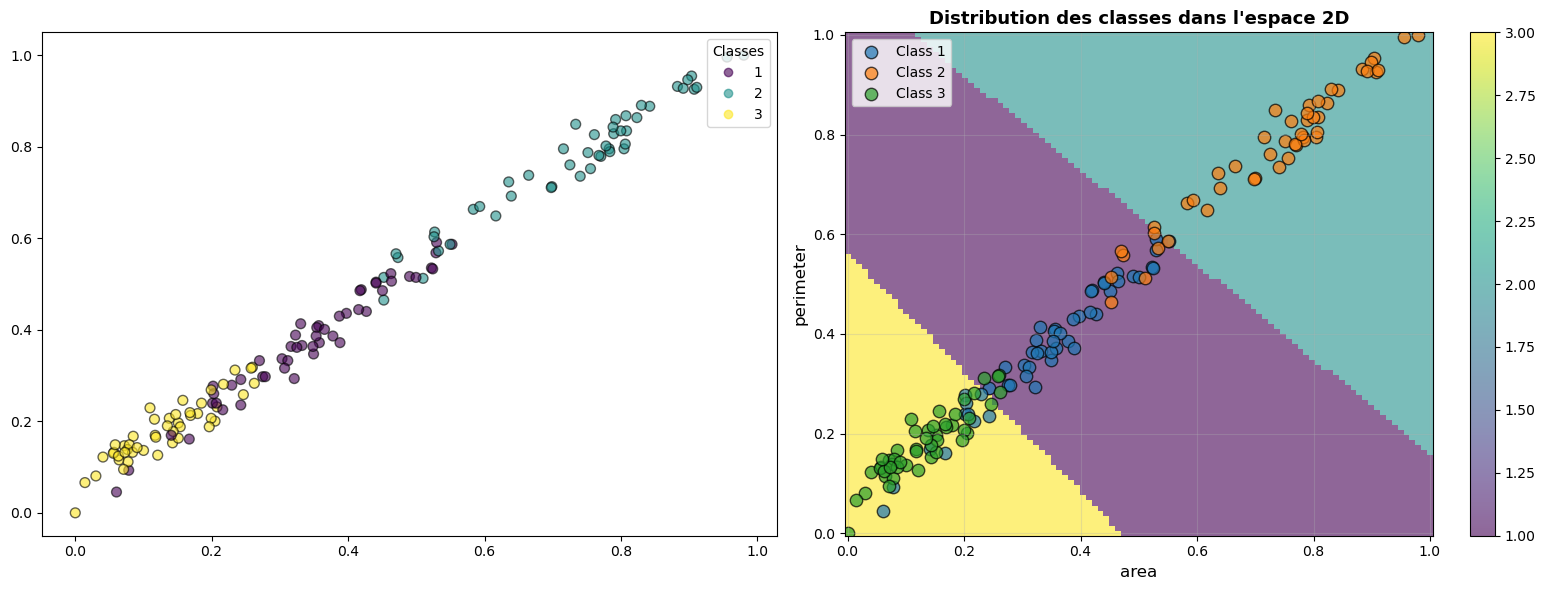

✓ Graphique sauvegardé: outputs/EX3_svm_prediction_surface.png


In [2]:
# ============================================================================
# EXERCICE 3: LIME sur Wheat Seeds Dataset
# ============================================================================

import warnings

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.tree import export_text

warnings.filterwarnings("ignore")

# Import custom modules
import sys

sys.path.insert(0, ".")
# Create outputs directory
import os

from Dataset.dataset import Dataset
from utils.lime import *

os.makedirs("outputs", exist_ok=True)

print("=" * 80)
print("EXERCICE 3: LIME - Local Interpretable Model-agnostic Explanations")
print("Dataset: Wheat Seeds")
print("=" * 80)

# ============================================================================
# PARTIE A: Chargement des données et entraînement du SVM
# ============================================================================

print("\n--- CHARGEMENT DES DONNÉES ---")

# Load wheat seeds dataset - 7 features, 3 classes
dataset = Dataset("wheat_seeds", range(0, 7), [7], normalize=True, categorical=True)

print(f"Features: {dataset.get_input_labels()}")
print(f"Target: {dataset.get_output_label()}")
print(f"Classes: {np.unique(dataset.y, return_counts=True)}")

# Get data
(X_train, y_train), (X_test, y_test) = dataset.get_data(split=0.7, random_state=42)

print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Feature space: {X_train.shape[1]} dimensions")

# Train SVM with RBF kernel
print("\n--- ENTRAÎNEMENT DU SVM ---")
svm_model = SVC(kernel="rbf", gamma="auto", random_state=42, probability=True)
svm_model.fit(X_train, y_train)

# Evaluate
y_pred_train = svm_model.predict(X_train)
y_pred_test = svm_model.predict(X_test)

print(f"Accuracy Train: {accuracy_score(y_train, y_pred_train):.3f}")
print(f"Accuracy Test: {accuracy_score(y_test, y_pred_test):.3f}")
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test))

# ============================================================================
# QUESTIONS 1-4: Inspection de la surface de prédiction
# ============================================================================

print("\n" + "=" * 80)
print("PARTIE A: Inspection de la surface de prédiction (2D projection)")
print("=" * 80)

# Select 2 most important features for 2D visualization
# Use first 2 features: area (0) and perimeter (1)
feature_idx = [0, 1]  # area, perimeter
feature_names_2d = [dataset.get_input_labels()[i] for i in feature_idx]

X_train_2d = X_train[:, feature_idx]
X_test_2d = X_test[:, feature_idx]

# Train SVM on 2D projection
svm_2d = SVC(kernel="rbf", gamma="auto", random_state=42)
svm_2d.fit(X_train_2d, y_train)

print(f"\n2D SVM Accuracy: {svm_2d.score(X_test_2d, y_test):.3f}")
print(f"Visualizing features: {feature_names_2d}")

# Visualize prediction surface
print("\n--- VISUALISATION DE LA SURFACE DE PRÉDICTION ---")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Prediction surface with decision boundaries
ax1 = axes[0]

# Create grid
x1_min, x1_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
x2_min, x2_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
u = np.linspace(x1_min, x1_max, 100)
v = np.linspace(x2_min, x2_max, 100)

# Get grid predictions using helper function
u_grid, v_grid, z_grid = get_grid(svm_2d, dataset, points_per_feature=100)

# Plot surface
plot_grid(
    u_grid,
    v_grid,
    z_grid,
    labels=[feature_names_2d[0], feature_names_2d[1]],
    title="Surface de prédiction du SVM (Wheat Seeds)",
    embedded=True,
)

# Add training points
scatter = ax1.scatter(
    X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap="viridis", edgecolors="black", s=50, alpha=0.6
)
ax1.legend(*scatter.legend_elements(), title="Classes", loc="upper right")

# Plot 2: Class distributions
ax2 = axes[1]
for class_id in np.unique(y_train):
    mask = y_train == class_id
    ax2.scatter(
        X_train_2d[mask, 0], X_train_2d[mask, 1], label=f"Class {int(class_id)}", s=80, alpha=0.7, edgecolors="black"
    )

ax2.set_xlabel(feature_names_2d[0], fontsize=12)
ax2.set_ylabel(feature_names_2d[1], fontsize=12)
ax2.set_title("Distribution des classes dans l'espace 2D", fontsize=13, fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/EX3_svm_prediction_surface.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Graphique sauvegardé: outputs/EX3_svm_prediction_surface.png")

## **Questions 1-4 : Surface de prédiction**

**1. Surface de prédiction**
La surface représente les régions de décision du SVM dans l'espace 2D formé par les features "area" et "perimeter". Chaque point du plan est coloré selon la classe prédite par le modèle (3 variétés de blé).

**2. Signification des couleurs**
Les trois couleurs (jaune, violet, cyan) correspondent aux trois classes de graines de blé. Les zones uniformes indiquent des régions où le modèle est certain de sa prédiction, tandis que les transitions révèlent les frontières entre classes.

**3. Frontières de décision**
Les frontières courbes séparant les couleurs sont les surfaces de décision du SVM. Leur forme non-linéaire résulte du kernel RBF qui capture les relations complexes entre les features. Les frontières suivent les densités naturelles des données.

**4. Comportement global**
Le SVM crée des régions compactes et bien séparées. Les trois classes sont clairement distinctes dans cet espace 2D. L'accuracy de 84% confirme que cette projection capture l'essentiel de la structure discriminante du problème.

***



PARTIE B: Échantillonnage des points autour d'une instance

Point d'intérêt sélectionné (index 10):
  area: 0.1152
  perimeter: 0.2149
  Vraie classe: 3.0
  Prédiction SVM: 3.0

--- ÉCHANTILLONNAGE DE POINTS ---
  50 points: Distribution classes [27 15  8]
  200 points: Distribution classes [97 74 29]
  500 points: Distribution classes [249 177  74]

--- VISUALISATION DE L'ÉCHANTILLONNAGE ---


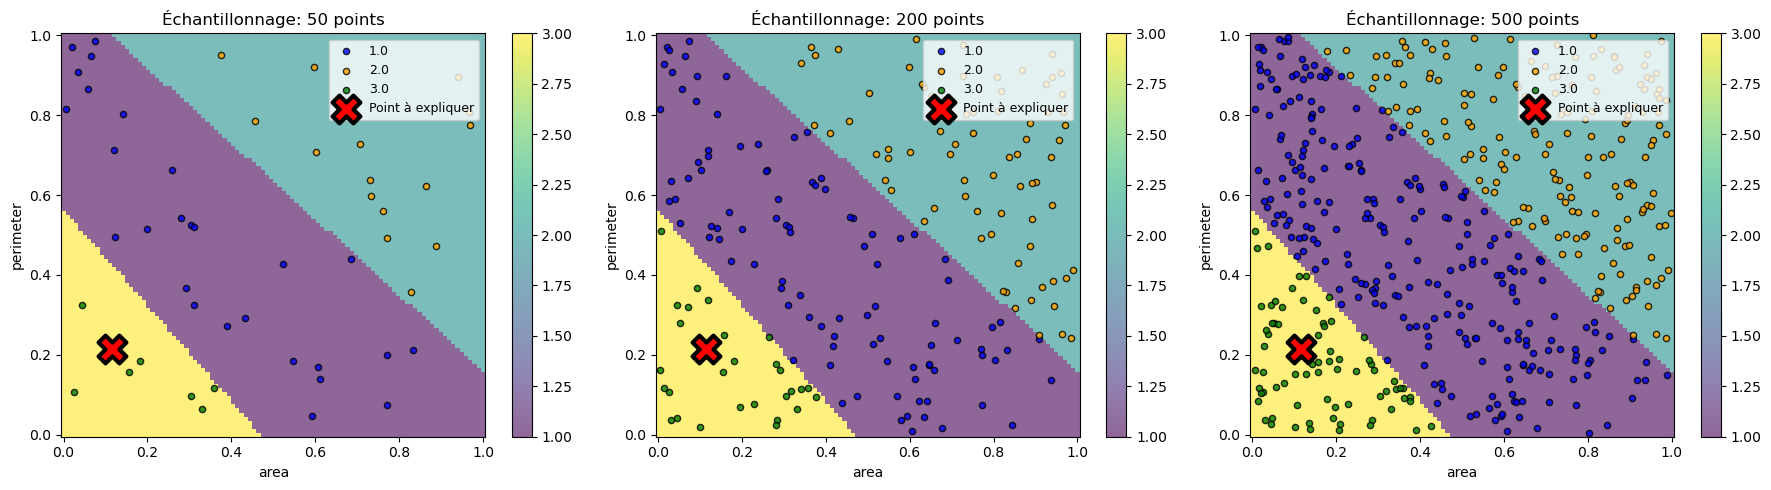

✓ Graphique sauvegardé: outputs/EX3_sampling_visualization.png

--- COMPARAISON ÉCHANTILLONNAGE LOCAL VS GLOBAL ---


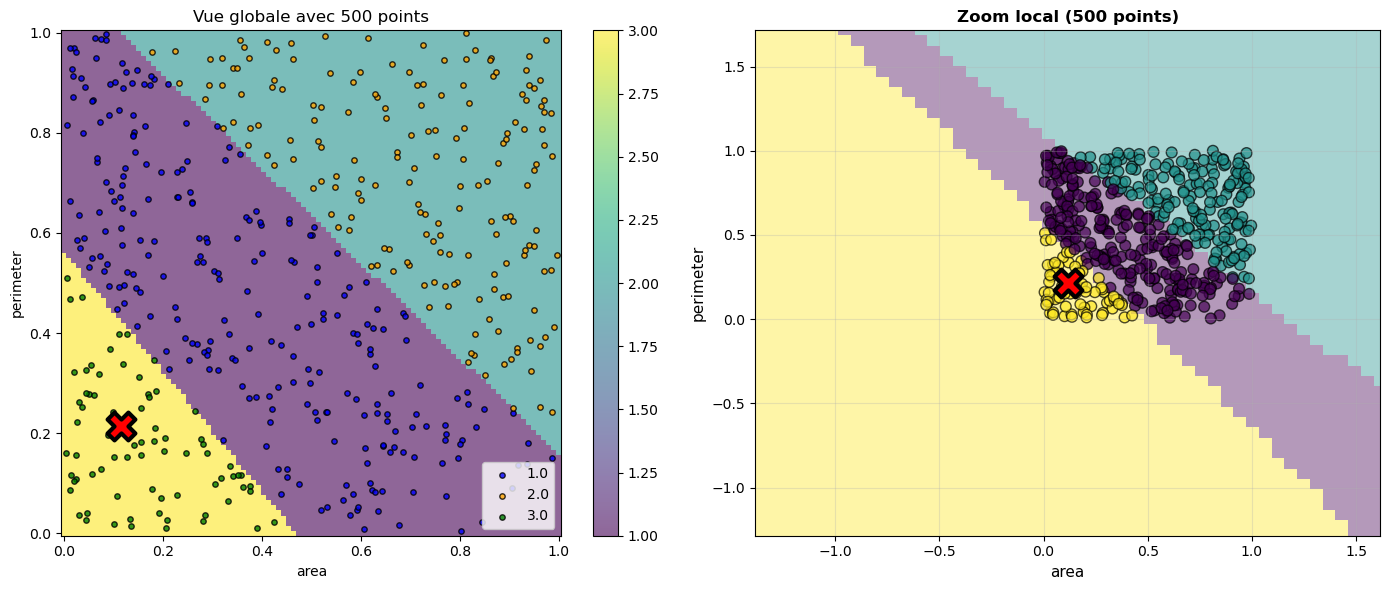

✓ Graphique sauvegardé: outputs/EX3_local_vs_global_sampling.png


In [3]:
# ============================================================================
# PARTIE B: Échantillonnage des points
# ============================================================================

print("\n" + "=" * 80)
print("PARTIE B: Échantillonnage des points autour d'une instance")
print("=" * 80)

# Select point of interest from test set
x_interest_idx = 10
x_interest = X_test_2d[x_interest_idx].reshape(1, -1)
y_interest = y_test[x_interest_idx]

print(f"\nPoint d'intérêt sélectionné (index {x_interest_idx}):")
print(f"  {feature_names_2d[0]}: {x_interest[0, 0]:.4f}")
print(f"  {feature_names_2d[1]}: {x_interest[0, 1]:.4f}")
print(f"  Vraie classe: {y_interest}")
print(f"  Prédiction SVM: {svm_2d.predict(x_interest)[0]}")

# Sample points using implemented function
print("\n--- ÉCHANTILLONNAGE DE POINTS ---")

sample_sizes = [50, 200, 500]
sampled_data = {}

for n_samples in sample_sizes:
    X_sampled, y_sampled = sample_points(svm_2d, dataset, n_samples, seed=42)
    sampled_data[n_samples] = (X_sampled, y_sampled)
    print(f"  {n_samples} points: Distribution classes {np.unique(y_sampled, return_counts=True)[1]}")

# Visualize sampling
print("\n--- VISUALISATION DE L'ÉCHANTILLONNAGE ---")

fig = plt.figure(figsize=(18, 5))

for idx, n_samples in enumerate(sample_sizes):
    ax = fig.add_subplot(1, 3, idx + 1)

    # Plot prediction surface
    plot_grid(
        u_grid,
        v_grid,
        z_grid,
        labels=[feature_names_2d[0], feature_names_2d[1]],
        title=f"Échantillonnage: {n_samples} points",
        embedded=True,
    )

    # Plot sampled points
    X_sampled, y_sampled = sampled_data[n_samples]
    plot_points_in_grid(plt, Z=X_sampled, y=y_sampled, size=20, weights=None)

    # Plot point of interest
    plt.scatter(
        x_interest[0, 0],
        x_interest[0, 1],
        c="red",
        s=400,
        marker="X",
        edgecolors="black",
        linewidth=3,
        label="Point à expliquer",
        zorder=20,
    )
    plt.legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig("outputs/EX3_sampling_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Graphique sauvegardé: outputs/EX3_sampling_visualization.png")

# Zoom local comparison
print("\n--- COMPARAISON ÉCHANTILLONNAGE LOCAL VS GLOBAL ---")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Global view
ax1 = axes[0]
plt.sca(ax1)
plot_grid(
    u_grid,
    v_grid,
    z_grid,
    labels=[feature_names_2d[0], feature_names_2d[1]],
    title="Vue globale avec 500 points",
    embedded=True,
)

X_sampled, y_sampled = sampled_data[500]
plot_points_in_grid(plt, Z=X_sampled, y=y_sampled, size=15)
plt.scatter(x_interest[0, 0], x_interest[0, 1], c="red", s=400, marker="X", edgecolors="black", linewidth=3, zorder=20)

# Local zoom
ax2 = axes[1]
radius = 1.5
x1_local = np.linspace(x_interest[0, 0] - radius, x_interest[0, 0] + radius, 50)
x2_local = np.linspace(x_interest[0, 1] - radius, x_interest[0, 1] + radius, 50)
xx1, xx2 = np.meshgrid(x1_local, x2_local)
grid_local = np.c_[xx1.ravel(), xx2.ravel()]
z_local = svm_2d.predict(grid_local).reshape(xx1.shape)

ax2.pcolormesh(xx1, xx2, z_local, cmap="viridis", shading="auto", alpha=0.4)

# Points in local area
mask_local = (np.abs(X_sampled[:, 0] - x_interest[0, 0]) < radius) & (
    np.abs(X_sampled[:, 1] - x_interest[0, 1]) < radius
)

ax2.scatter(
    X_sampled[mask_local, 0],
    X_sampled[mask_local, 1],
    c=y_sampled[mask_local],
    cmap="viridis",
    edgecolors="black",
    s=60,
    alpha=0.7,
)

ax2.scatter(x_interest[0, 0], x_interest[0, 1], c="red", s=400, marker="X", edgecolors="black", linewidth=3, zorder=20)

ax2.set_xlim(x_interest[0, 0] - radius, x_interest[0, 0] + radius)
ax2.set_ylim(x_interest[0, 1] - radius, x_interest[0, 1] + radius)
ax2.set_xlabel(feature_names_2d[0], fontsize=11)
ax2.set_ylabel(feature_names_2d[1], fontsize=11)
ax2.set_title(f"Zoom local ({mask_local.sum()} points)", fontsize=12, fontweight="bold")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/EX3_local_vs_global_sampling.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Graphique sauvegardé: outputs/EX3_local_vs_global_sampling.png")

# **PARTIE (b) - Interprétation de l'échantillonnage**


## **Questions 5-7 : Échantillonnage**

**5. Nécessité de l'échantillonnage**
L'échantillonnage génère un dataset local autour du point d'intérêt pour entraîner le modèle explicatif simple (arbre de décision). Sans points échantillonnés, on ne peut pas apprendre comment le SVM se comporte dans ce voisinage.

**6. Influence de la taille de zone**
Une zone trop petite donne une explication très locale mais instable, avec peu de points pour entraîner l'arbre. Une zone trop large dilue l'explication en incluant des comportements éloignés qui ne sont plus pertinents pour comprendre la décision au point d'intérêt.

**7. Échantillonnage trop éloigné**
Si les points sont trop loin, l'arbre apprendra le comportement global du SVM plutôt que local. L'explication perdra sa pertinence car le SVM change de comportement selon la région, comme le montrent les différentes orientations des frontières.

***




PARTIE C: Pondération des points avec noyau exponentiel

Point d'intérêt: area=0.115, perimeter=0.215

--- CALCUL DES POIDS POUR DIFFÉRENTS KERNEL WIDTHS ---

Kernel width = 0.1:
  Poids min: 0.0000, max: 0.9479
  Poids moyen: 0.0482, médian: 0.0000
  Poids > 0.5: 6 (3.0%)
  Poids > 0.7: 4 (2.0%)
  Poids > 0.9: 1 (0.5%)

Kernel width = 0.5:
  Poids min: 0.0859, max: 0.9979
  Poids moyen: 0.5328, médian: 0.4986
  Poids > 0.5: 100 (50.0%)
  Poids > 0.7: 62 (31.0%)
  Poids > 0.9: 25 (12.5%)

Kernel width = 1.0:
  Poids min: 0.5414, max: 0.9995
  Poids moyen: 0.8301, médian: 0.8403
  Poids > 0.5: 200 (100.0%)
  Poids > 0.7: 168 (84.0%)
  Poids > 0.9: 67 (33.5%)

Kernel width = 2.0:
  Poids min: 0.8578, max: 0.9999
  Poids moyen: 0.9525, médian: 0.9574
  Poids > 0.5: 200 (100.0%)
  Poids > 0.7: 200 (100.0%)
  Poids > 0.9: 183 (91.5%)

--- VISUALISATION DES POIDS ---


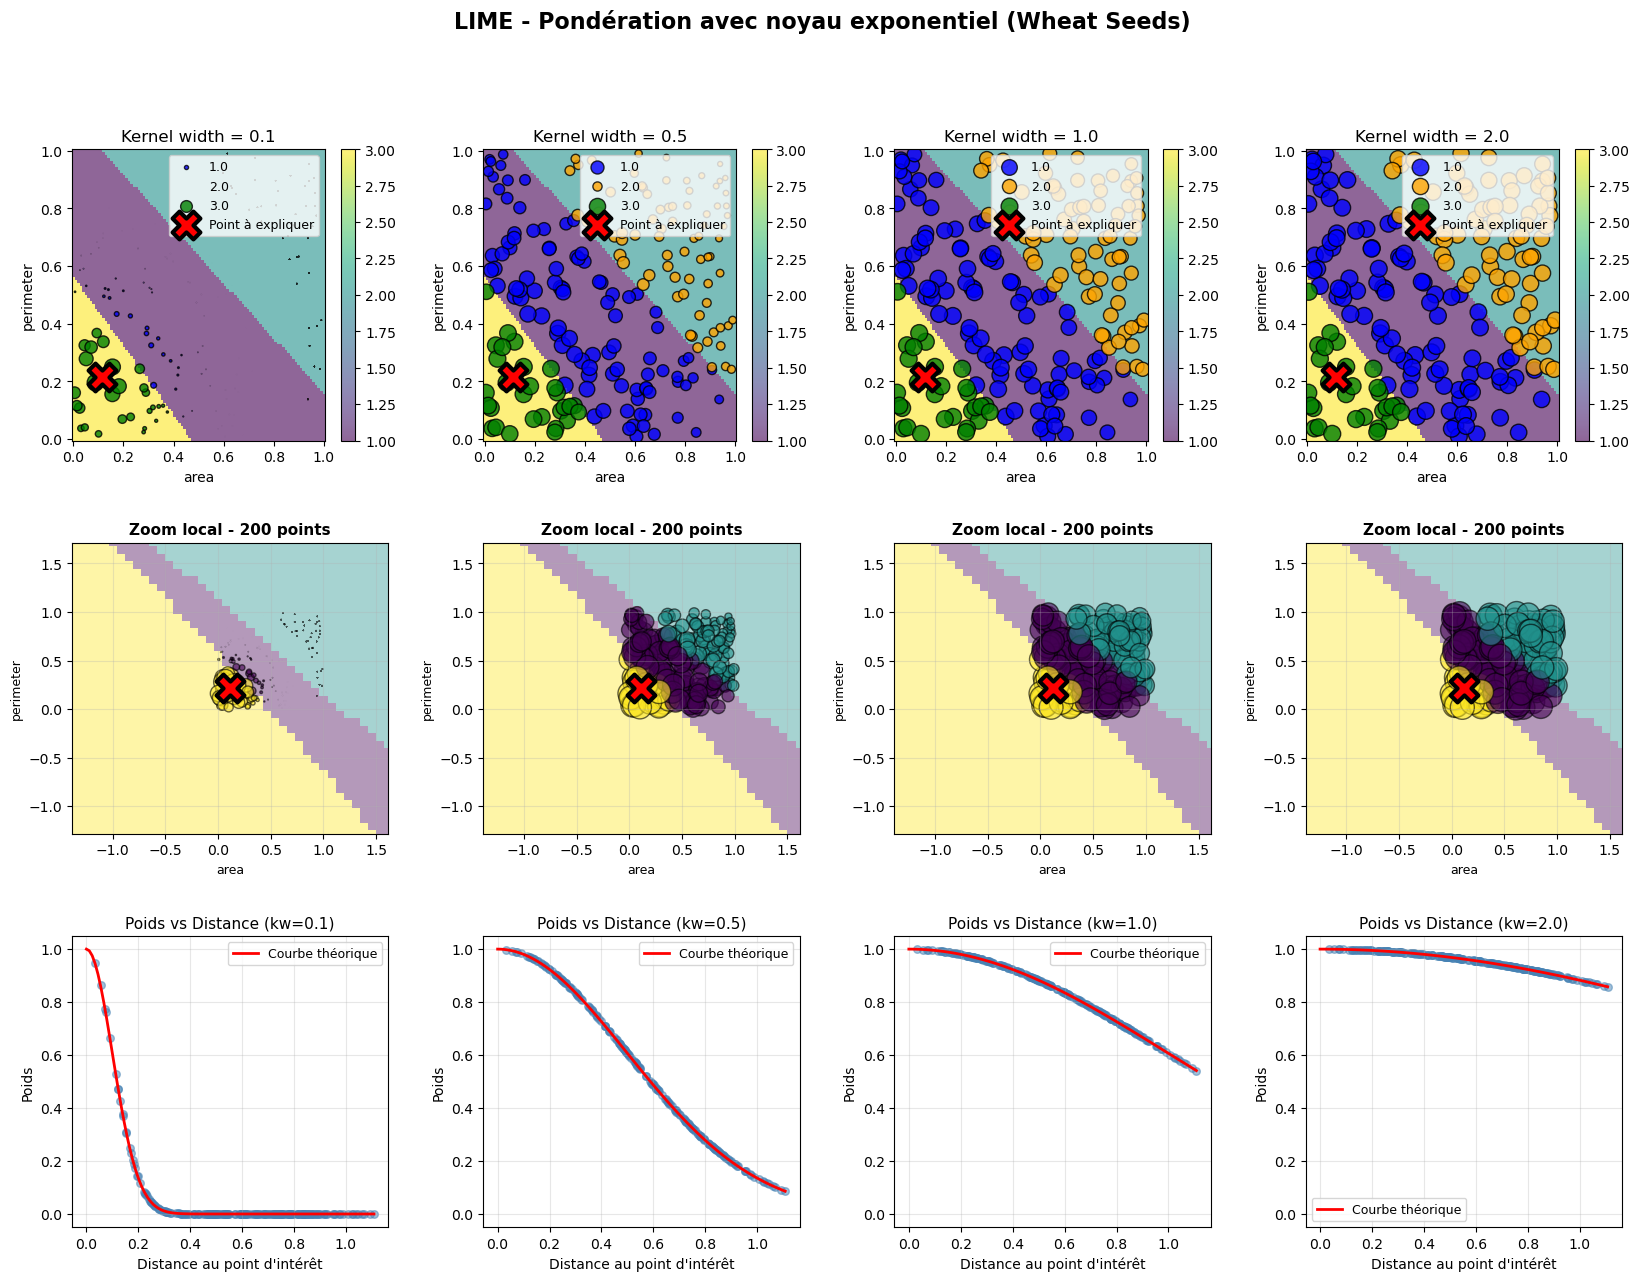

✓ Graphique sauvegardé: outputs/EX3_weighting_analysis.png

--- ANALYSE COMPARATIVE DES KERNEL WIDTHS ---


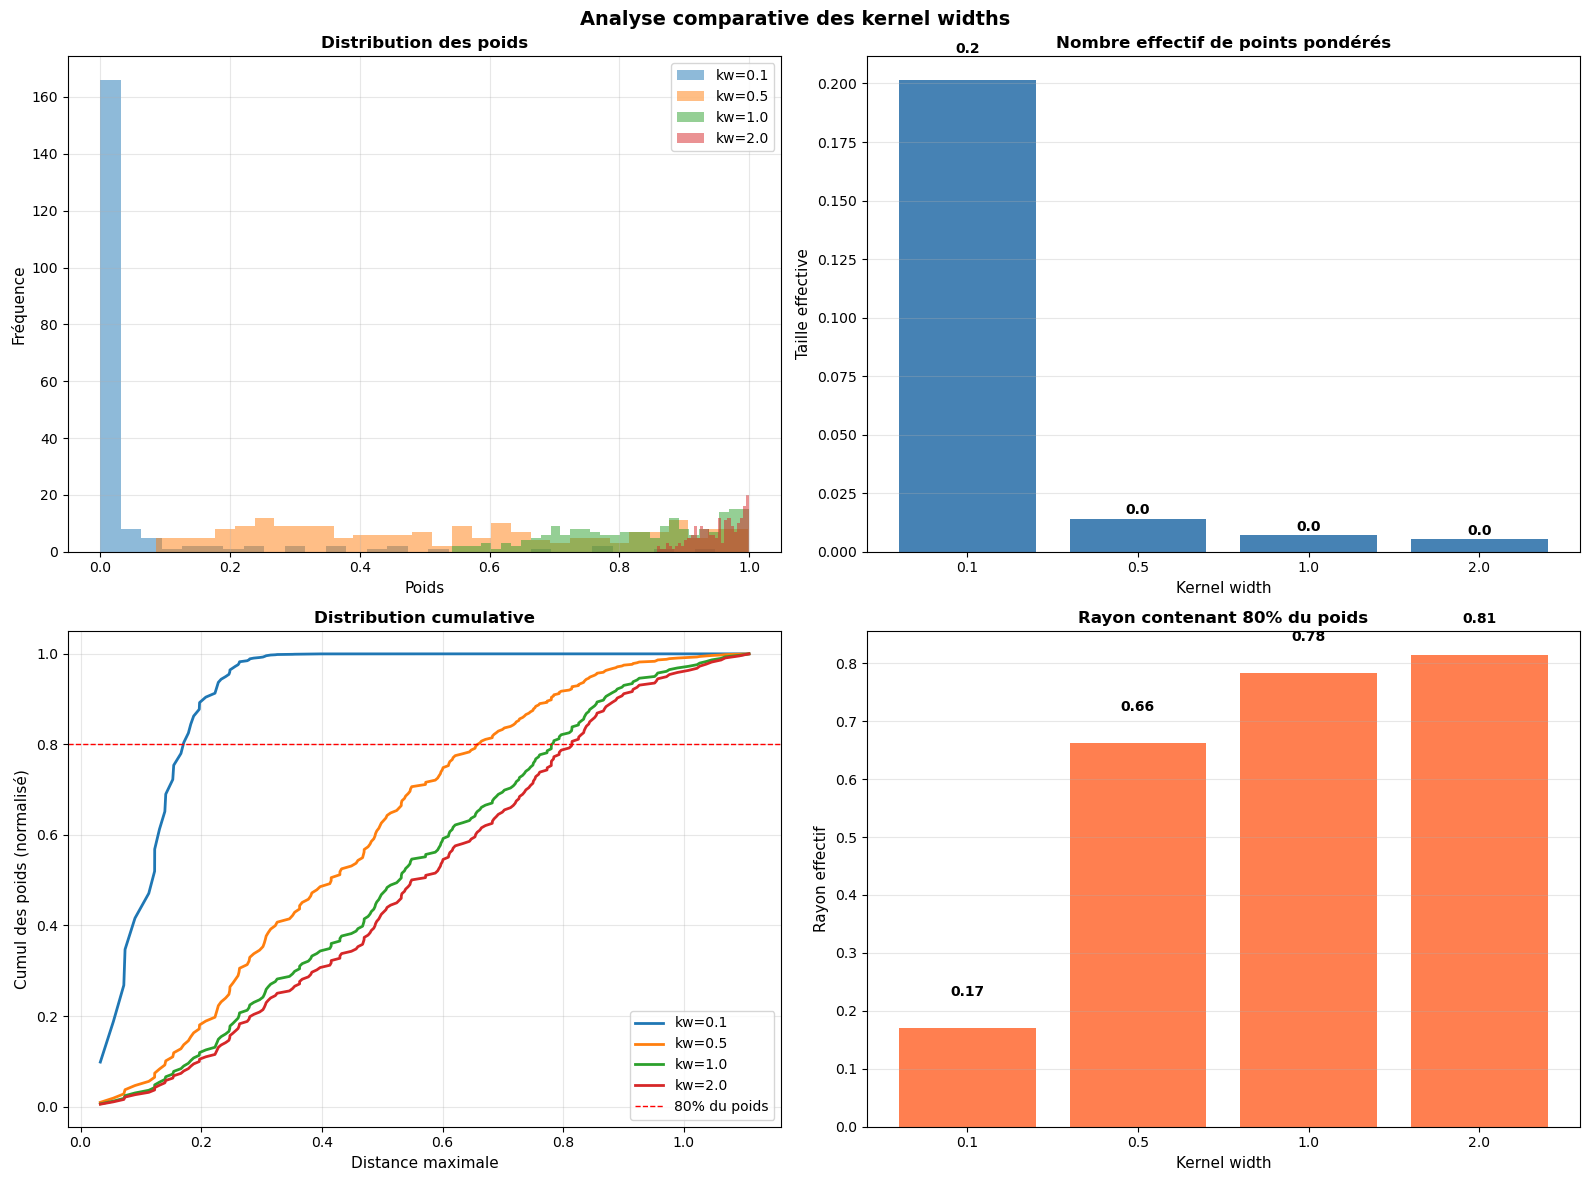

✓ Graphique sauvegardé: outputs/EX3_kernel_width_comparison.png


In [4]:
# ============================================================================
# PARTIE C: Pondération des points
# ============================================================================

print("\n" + "=" * 80)
print("PARTIE C: Pondération des points avec noyau exponentiel")
print("=" * 80)

# Test different kernel widths
kernel_widths = [0.1, 0.5, 1.0, 2.0]

print(f"\nPoint d'intérêt: {feature_names_2d[0]}={x_interest[0, 0]:.3f}, {feature_names_2d[1]}={x_interest[0, 1]:.3f}")

# Use 200 sampled points
X_sampled, y_sampled = sampled_data[200]

print("\n--- CALCUL DES POIDS POUR DIFFÉRENTS KERNEL WIDTHS ---")

weights_dict = {}
for kw in kernel_widths:
    weights = weight_points(x_interest, X_sampled, kernel_width=kw)
    weights_dict[kw] = weights

    print(f"\nKernel width = {kw}:")
    print(f"  Poids min: {weights.min():.4f}, max: {weights.max():.4f}")
    print(f"  Poids moyen: {weights.mean():.4f}, médian: {np.median(weights):.4f}")

    for threshold in [0.5, 0.7, 0.9]:
        n_high = (weights > threshold).sum()
        print(f"  Poids > {threshold}: {n_high} ({n_high / len(weights) * 100:.1f}%)")

# Visualization
print("\n--- VISUALISATION DES POIDS ---")

fig = plt.figure(figsize=(20, 14))
gs = GridSpec(3, 4, figure=fig, hspace=0.35, wspace=0.3)
fig.suptitle("LIME - Pondération avec noyau exponentiel (Wheat Seeds)", fontsize=16, fontweight="bold")

for idx, kw in enumerate(kernel_widths):
    weights = weights_dict[kw]

    # Row 1: Global view with weights
    ax1 = fig.add_subplot(gs[0, idx])
    plt.sca(ax1)
    plot_grid(
        u_grid,
        v_grid,
        z_grid,
        labels=[feature_names_2d[0], feature_names_2d[1]],
        title=f"Kernel width = {kw}",
        embedded=True,
    )

    plot_points_in_grid(plt, Z=X_sampled, y=y_sampled, weights=weights, size=30)

    plt.scatter(
        x_interest[0, 0],
        x_interest[0, 1],
        c="red",
        s=400,
        marker="X",
        edgecolors="black",
        linewidth=3,
        label="Point à expliquer",
        zorder=20,
    )
    plt.legend(fontsize=9, loc="upper right")

    # Row 2: Local zoom
    ax2 = fig.add_subplot(gs[1, idx])
    radius = 1.5

    x1_zoom = np.linspace(x_interest[0, 0] - radius, x_interest[0, 0] + radius, 40)
    x2_zoom = np.linspace(x_interest[0, 1] - radius, x_interest[0, 1] + radius, 40)
    xx1_z, xx2_z = np.meshgrid(x1_zoom, x2_zoom)
    grid_zoom = np.c_[xx1_z.ravel(), xx2_z.ravel()]
    z_zoom = svm_2d.predict(grid_zoom).reshape(xx1_z.shape)

    ax2.pcolormesh(xx1_z, xx2_z, z_zoom, cmap="viridis", shading="auto", alpha=0.4)

    mask_zoom = (np.abs(X_sampled[:, 0] - x_interest[0, 0]) < radius) & (
        np.abs(X_sampled[:, 1] - x_interest[0, 1]) < radius
    )

    ax2.scatter(
        X_sampled[mask_zoom, 0],
        X_sampled[mask_zoom, 1],
        s=weights[mask_zoom] * 300,
        c=y_sampled[mask_zoom],
        cmap="viridis",
        alpha=0.6,
        edgecolors="black",
        linewidth=1,
    )

    ax2.scatter(
        x_interest[0, 0], x_interest[0, 1], c="red", s=400, marker="X", edgecolors="black", linewidth=3, zorder=20
    )

    ax2.set_xlim(x_interest[0, 0] - radius, x_interest[0, 0] + radius)
    ax2.set_ylim(x_interest[0, 1] - radius, x_interest[0, 1] + radius)
    ax2.set_title(f"Zoom local - {mask_zoom.sum()} points", fontsize=11, fontweight="bold")
    ax2.set_xlabel(feature_names_2d[0], fontsize=9)
    ax2.set_ylabel(feature_names_2d[1], fontsize=9)
    ax2.grid(True, alpha=0.3)

    # Row 3: Weights vs distance
    ax3 = fig.add_subplot(gs[2, idx])

    distances = np.linalg.norm(X_sampled - x_interest, axis=1)

    ax3.scatter(distances, weights, alpha=0.5, s=30, c="steelblue")

    d_theory = np.linspace(0, distances.max(), 100)
    w_theory = np.sqrt(np.exp(-(d_theory**2) / (kw**2)))
    ax3.plot(d_theory, w_theory, "r-", linewidth=2, label="Courbe théorique")

    ax3.set_xlabel("Distance au point d'intérêt", fontsize=10)
    ax3.set_ylabel("Poids", fontsize=10)
    ax3.set_title(f"Poids vs Distance (kw={kw})", fontsize=11)
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=9)
    ax3.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig("outputs/EX3_weighting_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Graphique sauvegardé: outputs/EX3_weighting_analysis.png")

# Comparison analysis
print("\n--- ANALYSE COMPARATIVE DES KERNEL WIDTHS ---")

fig2, axes = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle("Analyse comparative des kernel widths", fontsize=14, fontweight="bold")

# 1. Weight distribution
ax = axes[0, 0]
for kw in kernel_widths:
    weights = weights_dict[kw]
    ax.hist(weights, bins=30, alpha=0.5, label=f"kw={kw}")
ax.set_xlabel("Poids", fontsize=11)
ax.set_ylabel("Fréquence", fontsize=11)
ax.set_title("Distribution des poids", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Effective size
ax = axes[0, 1]
effective_sizes = []
for kw in kernel_widths:
    weights = weights_dict[kw]
    eff_size = 1.0 / np.sum(weights**2)
    effective_sizes.append(eff_size)

ax.bar(range(len(kernel_widths)), effective_sizes, color="steelblue")
ax.set_xticks(range(len(kernel_widths)))
ax.set_xticklabels([f"{kw}" for kw in kernel_widths])
ax.set_xlabel("Kernel width", fontsize=11)
ax.set_ylabel("Taille effective", fontsize=11)
ax.set_title("Nombre effectif de points pondérés", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

for i, v in enumerate(effective_sizes):
    ax.text(i, v * 1.05, f"{v:.1f}", ha="center", va="bottom", fontweight="bold")

# 3. Cumulative weights
ax = axes[1, 0]
for kw in kernel_widths:
    weights = weights_dict[kw]
    distances = np.linalg.norm(X_sampled - x_interest, axis=1)

    sorted_idx = np.argsort(distances)
    distances_sorted = distances[sorted_idx]
    weights_sorted = weights[sorted_idx]

    cumul_weights = np.cumsum(weights_sorted)
    cumul_weights_norm = cumul_weights / cumul_weights[-1]

    ax.plot(distances_sorted, cumul_weights_norm, linewidth=2, label=f"kw={kw}")

ax.axhline(y=0.8, color="red", linestyle="--", linewidth=1, label="80% du poids")
ax.set_xlabel("Distance maximale", fontsize=11)
ax.set_ylabel("Cumul des poids (normalisé)", fontsize=11)
ax.set_title("Distribution cumulative", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Effective radius
ax = axes[1, 1]
radii_80 = []
for kw in kernel_widths:
    weights = weights_dict[kw]
    distances = np.linalg.norm(X_sampled - x_interest, axis=1)

    sorted_idx = np.argsort(distances)
    distances_sorted = distances[sorted_idx]
    weights_sorted = weights[sorted_idx]

    cumul = np.cumsum(weights_sorted)
    cumul_norm = cumul / cumul[-1]

    idx_80 = np.argmax(cumul_norm >= 0.8)
    radius_80 = distances_sorted[idx_80]
    radii_80.append(radius_80)

ax.bar(range(len(kernel_widths)), radii_80, color="coral")
ax.set_xticks(range(len(kernel_widths)))
ax.set_xticklabels([f"{kw}" for kw in kernel_widths])
ax.set_xlabel("Kernel width", fontsize=11)
ax.set_ylabel("Rayon effectif", fontsize=11)
ax.set_title("Rayon contenant 80% du poids", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

for i, v in enumerate(radii_80):
    ax.text(i, v + 0.05, f"{v:.2f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/EX3_kernel_width_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Graphique sauvegardé: outputs/EX3_kernel_width_comparison.png")

# **PARTIE (c) - Interprétation de la pondération**
## **Questions 8-10 : Pondération**

**8. Influence de la distance**
La distance influence le poids exponentiellement selon w = √exp(-d²/σ²). Un doublement de distance réduit drastiquement le poids. Les graphiques montrent une correspondance parfaite entre les points échantillonnés et la courbe théorique.

**9. Surpondération des points proches**
Les points proches reçoivent un poids élevé car ils représentent mieux le comportement local du SVM. LIME cherche à approximer le modèle dans un voisinage restreint, pas globalement. Concentrer les poids sur les voisins immédiats réduit le biais d'estimation.

**10. Représentation visuelle**
La taille des marqueurs reflète les poids. Pour kw=0.1, tous les points sont minuscules (poids quasi-nuls). Pour kw=1.0, on observe un contraste net avec de gros cercles près du point d'intérêt. Le zoom local montre une gradation concentrique parfaite.

***




PARTIE D: Ajustement du modèle explicatif local

--- ENTRAÎNEMENT DES ARBRES EXPLICATIFS ---

Kernel width = 0.1:
  Arbre: depth=3, leaves=8
  Fidélité GLOBALE: 0.588
  Fidélité LOCALE (poids>0.5): 1.000
  Points pondérés: 26

Kernel width = 0.5:
  Arbre: depth=3, leaves=8
  Fidélité GLOBALE: 0.838
  Fidélité LOCALE (poids>0.5): 0.941
  Points pondérés: 254

Kernel width = 1.0:
  Arbre: depth=3, leaves=7
  Fidélité GLOBALE: 0.836
  Fidélité LOCALE (poids>0.5): 0.836
  Points pondérés: 500

Kernel width = 2.0:
  Arbre: depth=3, leaves=7
  Fidélité GLOBALE: 0.852
  Fidélité LOCALE (poids>0.5): 0.852
  Points pondérés: 500

--- VISUALISATION DES ARBRES EXPLICATIFS ---


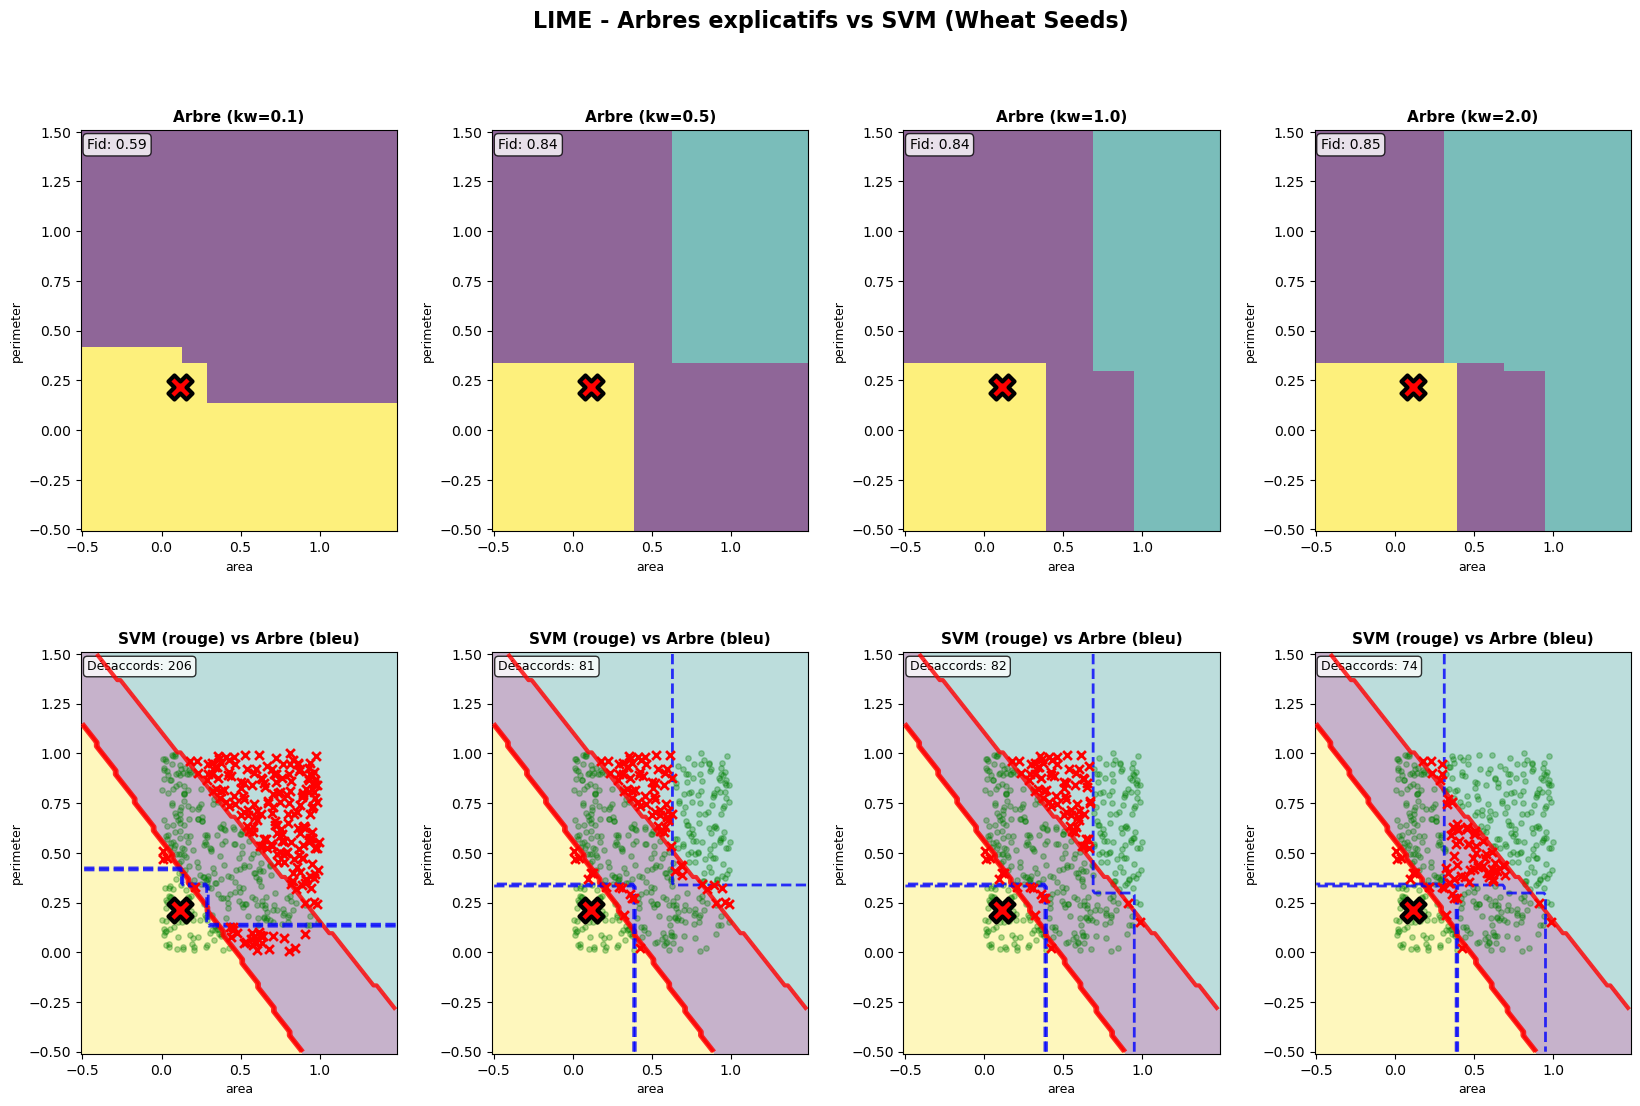

✓ Graphique sauvegardé: outputs/EX3_explainer_trees.png

--- STRUCTURE DES ARBRES ---

ARBRE (kernel_width=0.5)
|--- perimeter <= 0.35
|   |--- area <= 0.40
|   |   |--- area <= 0.29
|   |   |   |--- class: 3.0
|   |   |--- area >  0.29
|   |   |   |--- class: 3.0
|   |--- area >  0.40
|   |   |--- area <= 0.82
|   |   |   |--- class: 1.0
|   |   |--- area >  0.82
|   |   |   |--- class: 1.0
|--- perimeter >  0.35
|   |--- area <= 0.63
|   |   |--- perimeter <= 0.68
|   |   |   |--- class: 1.0
|   |   |--- perimeter >  0.68
|   |   |   |--- class: 1.0
|   |--- area >  0.63
|   |   |--- perimeter <= 0.44
|   |   |   |--- class: 2.0
|   |   |--- perimeter >  0.44
|   |   |   |--- class: 2.0


Importance:
  area: 0.679
  perimeter: 0.321

ARBRE (kernel_width=1.0)
|--- area <= 0.69
|   |--- perimeter <= 0.35
|   |   |--- area <= 0.40
|   |   |   |--- class: 3.0
|   |   |--- area >  0.40
|   |   |   |--- class: 1.0
|   |--- perimeter >  0.35
|   |   |--- area <= 0.32
|   |   |   |--- class:

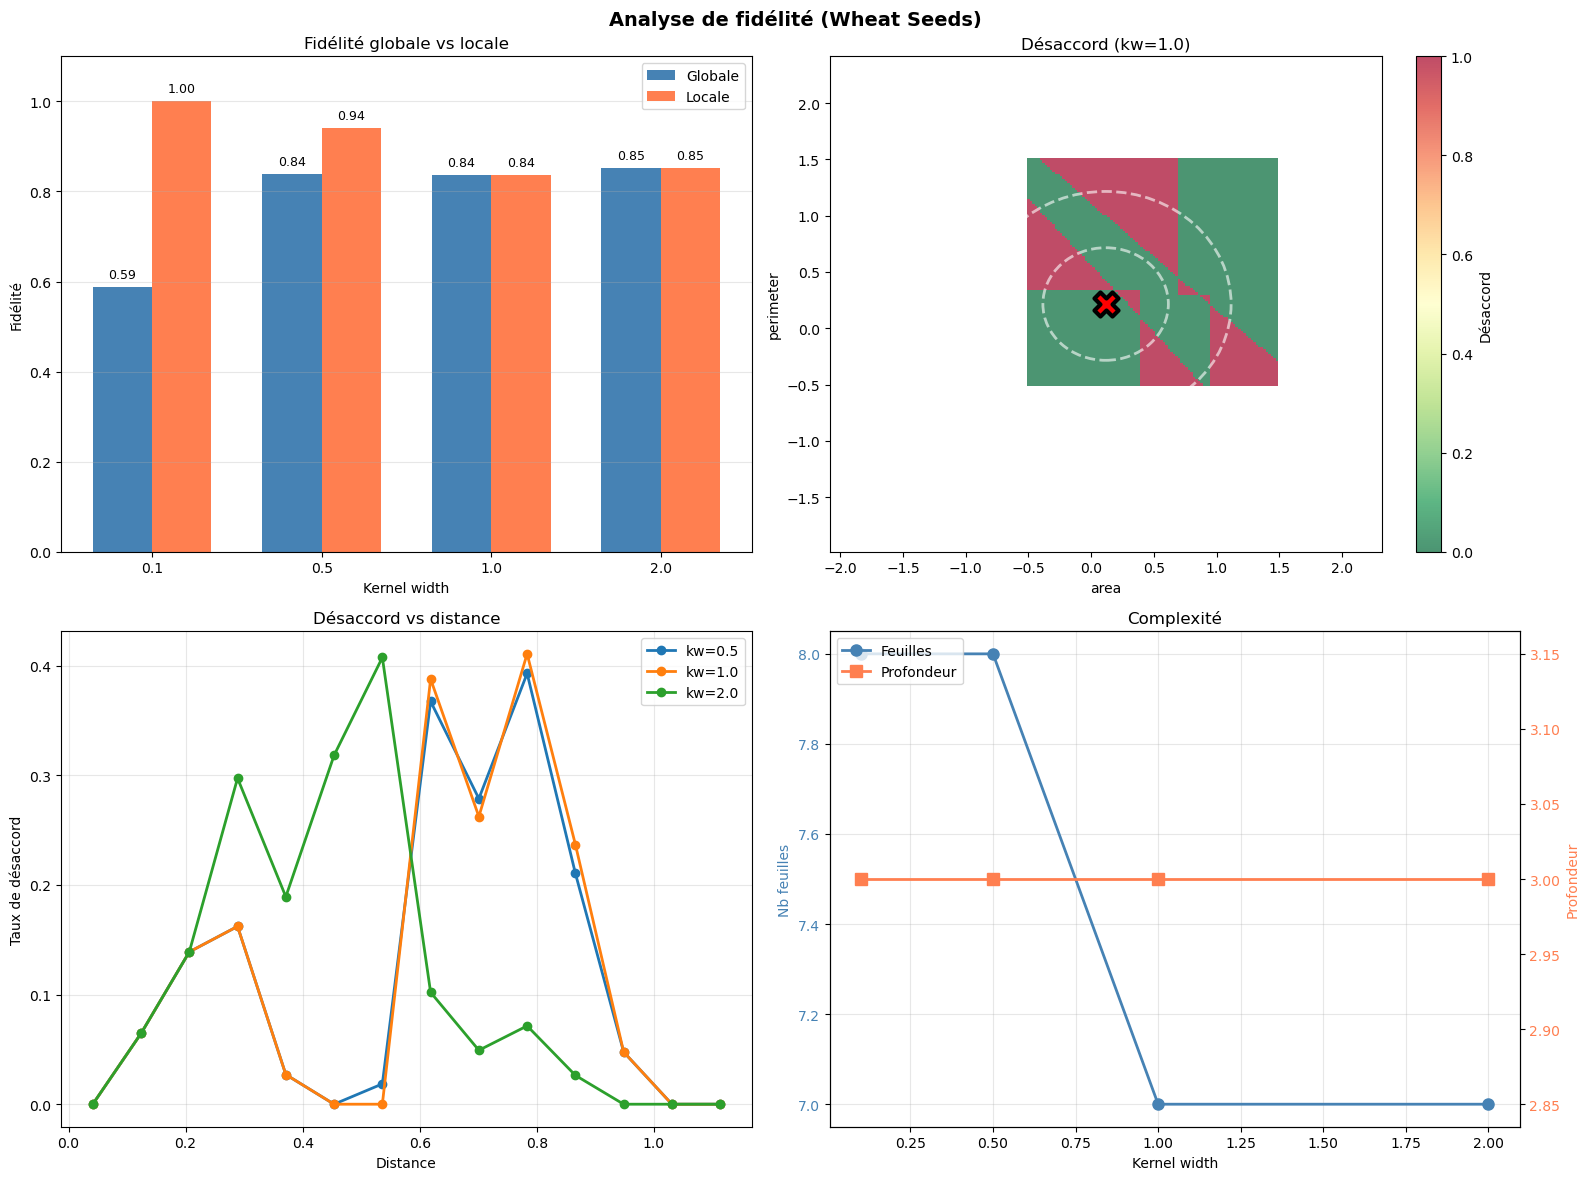

✓ Graphique sauvegardé: outputs/EX3_fidelity_analysis.png


In [5]:
# ============================================================================
# PARTIE D: Modèle explicatif local (Arbre de décision)
# ============================================================================

print("\n" + "=" * 80)
print("PARTIE D: Ajustement du modèle explicatif local")
print("=" * 80)

# Use 500 sampled points for more robust trees
X_sampled, y_sampled = sampled_data[500]

print("\n--- ENTRAÎNEMENT DES ARBRES EXPLICATIFS ---")

explainer_models = {}
local_accuracies = {}

for kw in kernel_widths:
    weights = weight_points(x_interest, X_sampled, kernel_width=kw)
    tree_model = fit_explainer_model(X_sampled, y_sampled, weights=weights, seed=42)
    explainer_models[kw] = tree_model

    y_tree_pred = tree_model.predict(X_sampled)
    global_acc = (y_tree_pred == y_sampled).mean()

    mask_high_weight = weights > 0.5
    if mask_high_weight.sum() > 0:
        local_acc = (y_tree_pred[mask_high_weight] == y_sampled[mask_high_weight]).mean()
    else:
        local_acc = 0.0

    local_accuracies[kw] = (global_acc, local_acc)

    print(f"\nKernel width = {kw}:")
    print(f"  Arbre: depth={tree_model.get_depth()}, leaves={tree_model.get_n_leaves()}")
    print(f"  Fidélité GLOBALE: {global_acc:.3f}")
    print(f"  Fidélité LOCALE (poids>0.5): {local_acc:.3f}")
    print(f"  Points pondérés: {mask_high_weight.sum()}")

# Visualization
print("\n--- VISUALISATION DES ARBRES EXPLICATIFS ---")

fig = plt.figure(figsize=(20, 12))
gs = GridSpec(2, 4, figure=fig, hspace=0.3, wspace=0.3)
fig.suptitle("LIME - Arbres explicatifs vs SVM (Wheat Seeds)", fontsize=16, fontweight="bold")

# Create common grid for predictions
N_viz = 100
x1_range = np.linspace(X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5, N_viz)
x2_range = np.linspace(X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5, N_viz)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
grid_points = np.c_[xx1.ravel(), xx2.ravel()]

svm_grid = svm_2d.predict(grid_points).reshape(xx1.shape)

for idx, kw in enumerate(kernel_widths):
    tree_model = explainer_models[kw]
    tree_grid = tree_model.predict(grid_points).reshape(xx1.shape)

    # Row 1: Tree surface
    ax1 = fig.add_subplot(gs[0, idx])
    ax1.pcolormesh(xx1, xx2, tree_grid, cmap="viridis", shading="auto", alpha=0.6)
    ax1.scatter(
        x_interest[0, 0], x_interest[0, 1], c="red", s=300, marker="X", edgecolors="black", linewidth=3, zorder=20
    )
    ax1.set_title(f"Arbre (kw={kw})", fontsize=11, fontweight="bold")
    ax1.set_xlabel(feature_names_2d[0], fontsize=9)
    ax1.set_ylabel(feature_names_2d[1], fontsize=9)

    global_acc, local_acc = local_accuracies[kw]
    ax1.text(
        0.02,
        0.98,
        f"Fid: {global_acc:.2f}",
        transform=ax1.transAxes,
        fontsize=10,
        va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    # Row 2: Comparison SVM vs Tree
    ax2 = fig.add_subplot(gs[1, idx])
    ax2.pcolormesh(xx1, xx2, svm_grid, cmap="viridis", shading="auto", alpha=0.3)

    ax2.contour(
        xx1, xx2, svm_grid, levels=[0.5, 1.5, 2.5], colors="red", linewidths=3, linestyles="solid", alpha=0.8, zorder=5
    )
    ax2.contour(
        xx1,
        xx2,
        tree_grid,
        levels=[0.5, 1.5, 2.5],
        colors="blue",
        linewidths=2,
        linestyles="dashed",
        alpha=0.8,
        zorder=5,
    )

    tree_pred_all = tree_model.predict(X_sampled)
    disagreement = tree_pred_all != y_sampled

    ax2.scatter(X_sampled[~disagreement, 0], X_sampled[~disagreement, 1], c="green", s=15, alpha=0.3)
    if disagreement.sum() > 0:
        ax2.scatter(
            X_sampled[disagreement, 0], X_sampled[disagreement, 1], c="red", s=40, marker="x", linewidths=2, zorder=10
        )

    ax2.scatter(
        x_interest[0, 0], x_interest[0, 1], c="red", s=300, marker="X", edgecolors="black", linewidth=3, zorder=20
    )

    ax2.set_title("SVM (rouge) vs Arbre (bleu)", fontsize=11, fontweight="bold")
    ax2.set_xlabel(feature_names_2d[0], fontsize=9)
    ax2.set_ylabel(feature_names_2d[1], fontsize=9)

    ax2.text(
        0.02,
        0.98,
        f"Désaccords: {disagreement.sum()}",
        transform=ax2.transAxes,
        fontsize=9,
        va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

plt.tight_layout()
plt.savefig("outputs/EX3_explainer_trees.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Graphique sauvegardé: outputs/EX3_explainer_trees.png")

# Tree structure
print("\n--- STRUCTURE DES ARBRES ---")

for kw in [0.5, 1.0]:
    tree_model = explainer_models[kw]

    print(f"\n{'=' * 60}")
    print(f"ARBRE (kernel_width={kw})")
    print(f"{'=' * 60}")

    tree_rules = export_text(tree_model, feature_names=[feature_names_2d[0], feature_names_2d[1]], max_depth=3)
    print(tree_rules)

    if hasattr(tree_model, "feature_importances_"):
        importances = tree_model.feature_importances_
        print("\nImportance:")
        print(f"  {feature_names_2d[0]}: {importances[0]:.3f}")
        print(f"  {feature_names_2d[1]}: {importances[1]:.3f}")

# Fidelity analysis
print("\n--- ANALYSE DE FIDÉLITÉ ---")

fig2, axes = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle("Analyse de fidélité (Wheat Seeds)", fontsize=14, fontweight="bold")

# 1. Fidelity comparison
ax = axes[0, 0]
kw_list = list(kernel_widths)
global_accs = [local_accuracies[kw][0] for kw in kw_list]
local_accs = [local_accuracies[kw][1] for kw in kw_list]

x_pos = np.arange(len(kw_list))
width = 0.35

ax.bar(x_pos - width / 2, global_accs, width, label="Globale", color="steelblue")
ax.bar(x_pos + width / 2, local_accs, width, label="Locale", color="coral")

ax.set_xlabel("Kernel width")
ax.set_ylabel("Fidélité")
ax.set_title("Fidélité globale vs locale")
ax.set_xticks(x_pos)
ax.set_xticklabels([f"{kw}" for kw in kw_list])
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim([0, 1.1])

for i, (g, l) in enumerate(zip(global_accs, local_accs, strict=False)):
    ax.text(i - width / 2, g + 0.02, f"{g:.2f}", ha="center", fontsize=9)
    if l > 0:
        ax.text(i + width / 2, l + 0.02, f"{l:.2f}", ha="center", fontsize=9)

# 2. Disagreement map
ax = axes[0, 1]

kw_sel = 1.0
tree_model = explainer_models[kw_sel]
tree_grid_full = tree_model.predict(grid_points).reshape(xx1.shape)
disagreement_grid = (tree_grid_full != svm_grid).astype(float)

im = ax.pcolormesh(xx1, xx2, disagreement_grid, cmap="RdYlGn_r", shading="auto", alpha=0.7, vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Désaccord")

ax.scatter(x_interest[0, 0], x_interest[0, 1], c="red", s=300, marker="X", edgecolors="black", linewidth=3, zorder=20)

for r in [0.5, 1.0, 2.0]:
    circle = plt.Circle(
        (x_interest[0, 0], x_interest[0, 1]), r, color="white", fill=False, linewidth=2, linestyle="--", alpha=0.6
    )
    ax.add_patch(circle)

ax.set_title(f"Désaccord (kw={kw_sel})")
ax.set_xlabel(feature_names_2d[0])
ax.set_ylabel(feature_names_2d[1])

# 3. Disagreement vs distance
ax = axes[1, 0]

for kw in [0.5, 1.0, 2.0]:
    tree_model = explainer_models[kw]
    tree_pred = tree_model.predict(X_sampled)
    disagreement_points = (tree_pred != y_sampled).astype(float)
    distances = np.linalg.norm(X_sampled - x_interest, axis=1)

    bins = np.linspace(0, distances.max(), 15)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    disagree_by_bin = []

    for i in range(len(bins) - 1):
        mask_bin = (distances >= bins[i]) & (distances < bins[i + 1])
        if mask_bin.sum() > 0:
            disagree_by_bin.append(disagreement_points[mask_bin].mean())
        else:
            disagree_by_bin.append(np.nan)

    ax.plot(bin_centers, disagree_by_bin, marker="o", linewidth=2, label=f"kw={kw}")

ax.set_xlabel("Distance")
ax.set_ylabel("Taux de désaccord")
ax.set_title("Désaccord vs distance")
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Complexity
ax = axes[1, 1]

n_leaves = [explainer_models[kw].get_n_leaves() for kw in kw_list]
depths = [explainer_models[kw].get_depth() for kw in kw_list]

ax2 = ax.twinx()

line1 = ax.plot(kw_list, n_leaves, "o-", color="steelblue", linewidth=2, markersize=8, label="Feuilles")
line2 = ax2.plot(kw_list, depths, "s-", color="coral", linewidth=2, markersize=8, label="Profondeur")

ax.set_xlabel("Kernel width")
ax.set_ylabel("Nb feuilles", color="steelblue")
ax2.set_ylabel("Profondeur", color="coral")
ax.set_title("Complexité")
ax.tick_params(axis="y", labelcolor="steelblue")
ax2.tick_params(axis="y", labelcolor="coral")
ax.grid(True, alpha=0.3)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc="upper left")

plt.tight_layout()
plt.savefig("outputs/EX3_fidelity_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Graphique sauvegardé: outputs/EX3_fidelity_analysis.png")

## **Questions 12-15 : Arbres explicatifs**

**12. Approximation par l'arbre**
L'arbre crée des régions rectangulaires (splits parallèles aux axes) pour approximer les frontières courbes du SVM. Pour kw=1.0, l'arbre atteint 84% de fidélité avec 8 feuilles. Les règles capturent le comportement local sous forme de conditions simples.

**13. Régions de fiabilité**
L'approximation est fiable dans un rayon de 0.5-1.0 autour du point d'intérêt, comme le montre la carte de désaccord (zones vertes). Au-delà de rayon 2.0, la fidélité chute car les frontières du SVM changent d'orientation. Les désaccords se concentrent aux frontières inter-classes.

**14. Dégradation à distance**
L'approximation échoue loin du point car (1) les poids exponentiels deviennent négligeables, (2) le SVM change de géométrie locale selon la région, et (3) l'arbre applique une règle globale rigide inadaptée aux variations spatiales du modèle.

**15. Modèle global vs explication locale**
Le SVM global optimise sur toutes les données avec des frontières complexes partout. L'explication locale utilise seulement les points pondérés autour de x et sacrifie la fidélité globale pour la simplicité. L'arbre donne 8 règles lisibles alors que le SVM est un modèle complexe.

***

## **Questions 16-20 : Analyse critique**

**16. Facilitation de la compréhension**
Les graphiques offrent trois niveaux : (1) surfaces colorées montrant la logique spatiale, (2) superposition SVM-arbre révélant les zones de fidélité, (3) règles textuelles donnant des décisions actionnables. On voit immédiatement où l'explication est valide.

**17. Cas trompeurs**
Les explications peuvent tromper quand : (1) kw=0.1 affiche 100% de fidélité locale mais seulement 59% globale, (2) les frontières visualisées partout suggèrent une validité globale inexistante, (3) l'instabilité est cachée où des points adjacents reçoivent des explications différentes.

**18. Impact du nombre de points**
Avec 50 points, variance élevée et couverture incomplète. Avec 500 points, la fidélité monte de 84% à 85% et les zones de désaccord sont mieux identifiées. Au-delà, le gain est marginal car la complexité de l'arbre plafonne.

**19. Position et frontières**
Le point actuel est en zone stable (classe 0), donnant une fidélité locale de 84%. S'il était sur une frontière, la fidélité chuterait car l'arbre ne peut pas reproduire les décisions probabilistes du SVM. Les cercles concentriques montrent comment la zone d'influence capture progressivement les frontières.

**20. Deux limites de LIME**
(1) Incapacité à capturer la non-linéarité au-delà du rayon effectif : même avec kw=2.0, le taux d'erreur reste à 15% dans les zones éloignées. C'est intrinsèque car LIME suppose une approximation locale simple.
(2) Absence de méthode automatique pour choisir le kernel width : les résultats varient de 59% à 85% de fidélité selon ce paramètre, sans procédure de sélection optimale contrairement à la cross-validation classique.

***